In [ ]:
import pandas as pd 
import numpy as np
import holidays

In [58]:
df = pd.read_csv("/Users/saif/Desktop/ML_Load_Forecasting/data/Silver/df_clean.csv", index_col= 0 , parse_dates=True)

In [59]:
df.head()

,Load_MW,temperature_2m,wind_speed_10m,shortwave_radiation
2020-01-01 00:00:00,43471.87,1.5,11.4,0.0
2020-01-01 01:00:00,42401.86,2.0,10.3,0.0
2020-01-01 02:00:00,41126.54,1.8,11.2,0.0
2020-01-01 03:00:00,40793.28,1.1,10.1,0.0
2020-01-01 04:00:00,40710.44,0.3,9.4,0.0


In [60]:
day_of_week = df.index.dayofweek
hour = df.index.hour
month = df.index.month
de_holiday = holidays.Germany(years=[2020, 2021, 2022, 2023])

df["is_weekend"] = (day_of_week >= 5).astype(int)

df['is_holiday'] = df.index.date

df['is_holiday'] = df['is_holiday'].apply(lambda x: 1 if x in de_holiday else 0)

df["is_rest_day"] = ((df["is_weekend"] == 1) | (df["is_holiday"] == 1)).astype(int)

df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * hour / 24)
df["day_sin"] = np.sin(2 * np.pi * day_of_week / 7)
df["day_cos"] = np.cos(2 * np.pi * day_of_week / 7)
df["month_sin"] = np.sin(2 * np.pi * month / 12)
df["month_cos"] = np.cos(2 * np.pi * month / 12)

df["lag_day"] = df["Load_MW"].shift(24)
df["lag_week"] = df["Load_MW"].shift(168)
df["lag_2week"] = df["Load_MW"].shift(336)

df["rolling_mean_week"] = df["Load_MW"].shift(24).rolling(168).mean()



In [61]:
print(df.describe())
print(f"Total holidays found: {df['is_holiday'].sum()}")
print(df.head(1))

            Load_MW  temperature_2m  wind_speed_10m  shortwave_radiation  \
count  35064.000000    35064.000000    35064.000000         35064.000000   
mean   55663.000968       10.798825       13.608450           130.343058   
std     9832.006622        8.091027        6.525289           202.071853   
min    28407.440000      -14.900000        0.000000             0.000000   
25%    47737.085000        4.600000        8.700000             0.000000   
50%    55595.070000       10.200000       12.500000             5.000000   
75%    63244.437500       16.800000       17.400000           201.000000   
max    81966.910000       37.700000       49.700000           868.000000   

         is_weekend    is_holiday   is_rest_day      hour_sin      hour_cos  \
count  35064.000000  35064.000000  35064.000000  3.506400e+04  3.506400e+04   
mean       0.286105      0.024641      0.303901 -1.172789e-17 -6.010858e-17   
std        0.451946      0.155030      0.459947  7.071169e-01  7.071169e-01   

In [62]:

df.dropna(inplace=True)
df.isna().sum()

Load_MW                0
temperature_2m         0
wind_speed_10m         0
shortwave_radiation    0
is_weekend             0
is_holiday             0
is_rest_day            0
hour_sin               0
hour_cos               0
day_sin                0
day_cos                0
month_sin              0
month_cos              0
lag_day                0
lag_week               0
lag_2week              0
rolling_mean_week      0
dtype: int64

### Version B - DAY AHEAD WITHOUT LAG FEATURES 

In [63]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.svm import LinearSVR


import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
features_B = [
    'temperature_2m', 'wind_speed_10m', 'shortwave_radiation',
    'is_weekend', 'is_holiday', 'is_rest_day',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos'
]

df = df.dropna()

In [65]:
X_train_raw = df[df.index.year < 2023][features_B]
X_test_raw  = df[df.index.year == 2023][features_B]

y_train_raw = df[df.index.year < 2023][['Load_MW']]
y_test_raw  = df[df.index.year == 2023][['Load_MW']]

In [66]:
# 4. Skalierung (Wichtig für LSTM-Stabilität)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Fit nur auf Training, Transform auf beides
X_train = scaler_X.fit_transform(X_train_raw)
X_test  = scaler_X.transform(X_test_raw)

y_train = scaler_y.fit_transform(y_train_raw)
y_test  = scaler_y.transform(y_test_raw)

# 5. Kontrolle der Dimensionen
print("--- Version B: Bereit für Training ---")
print(f"Features: {len(features_B)}")
print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape:  {X_test.shape}")
print(f"Mittelwert y_train (sollte ~0 sein): {y_train.mean():.4f}")

--- Version B: Bereit für Training ---
Features: 12
X_train Shape: (25968, 12)
X_test Shape:  (8760, 12)
Mittelwert y_train (sollte ~0 sein): 0.0000


In [67]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train.ravel()) # Wir nutzen die skalierten Daten von eben
y_lr_pred_scaled = lr_model.predict(X_test)
y_lr_predict = scaler_y.inverse_transform(y_lr_pred_scaled.reshape(-1, 1)).ravel()

# SVM (LinearSVR)
svm_model = LinearSVR(C=1.0, max_iter=10000, dual='auto')
svm_model.fit(X_train, y_train.ravel())
y_svm_pred_scaled = svm_model.predict(X_test)
y_svm_predict = scaler_y.inverse_transform(y_svm_pred_scaled.reshape(-1, 1)).ravel()


# XGBoost
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train.ravel())
y_xgb_pred_scaled = xgb_model.predict(X_test)
y_xgb_predict = scaler_y.inverse_transform(y_xgb_pred_scaled.reshape(-1, 1)).ravel()

In [68]:
def print_metrics(name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)
    print(f"{name:15} | MAE: {mae:4.0f} MW | RMSE: {rmse:4.0f} MW | R²: {r2:.4f}")


print_metrics("Linear Reg", y_test_raw, y_lr_predict)
print_metrics("SVM",        y_test_raw, y_svm_predict)
print_metrics("XGBoost",    y_test_raw, y_xgb_predict)

Linear Reg      | MAE: 4421 MW | RMSE: 5505 MW | R²: 0.6428
SVM             | MAE: 4508 MW | RMSE: 5625 MW | R²: 0.6271
XGBoost         | MAE: 3802 MW | RMSE: 4451 MW | R²: 0.7665


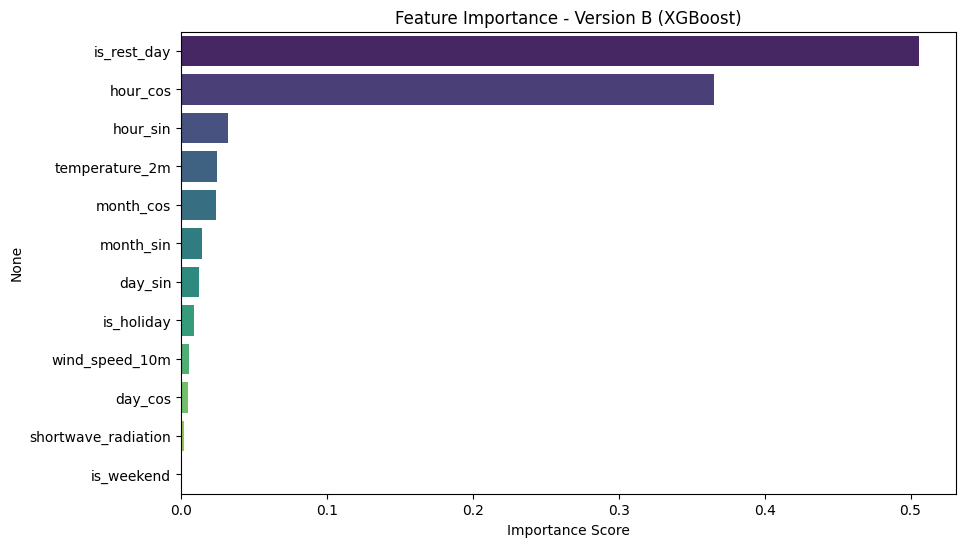

In [69]:
# Feature Importance von XGBoost
importances = xgb_model.feature_importances_
feat_importance = pd.Series(importances, index=features_B).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importance.values, y=feat_importance.index, hue=feat_importance.index, palette="viridis", legend=False)
plt.title("Feature Importance - Version B (XGBoost)")
plt.xlabel("Importance Score")
plt.show()

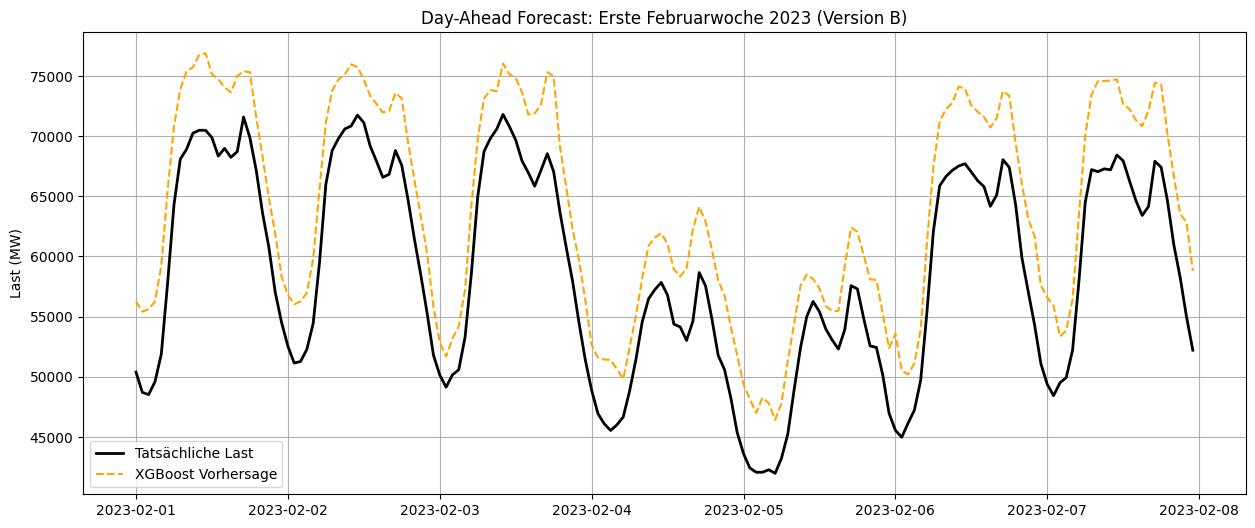

In [70]:

results_df = pd.DataFrame({
    'Actual': y_test_raw.values.ravel(),
    'XGBoost': y_xgb_predict
}, index=y_test_raw.index)

# Plot 1. Feb bis 7. Feb 2023
plt.figure(figsize=(15, 6))
plt.plot(results_df.loc['2023-02-01':'2023-02-07', 'Actual'], label='Tatsächliche Last', color='black', linewidth=2)
plt.plot(results_df.loc['2023-02-01':'2023-02-07', 'XGBoost'], label='XGBoost Vorhersage', color='orange', linestyle='--')
plt.title("Day-Ahead Forecast: Erste Februarwoche 2023 (Version B)")
plt.ylabel("Last (MW)")
plt.legend()
plt.grid(True)
plt.show()

In [71]:

persistence_actual = df[df.index.year == 2023]['Load_MW']
persistence_pred = df[df.index.year == 2023]['lag_day']

mae_pers = mean_absolute_error(persistence_actual, persistence_pred)
rmse_pers = np.sqrt(mean_squared_error(persistence_actual, persistence_pred))
r2_pers = r2_score(persistence_actual, persistence_pred)


print(f"PERSISTENCE (Day) | MAE: {mae_pers:4.0f} MW | RMSE: {rmse_pers:4.0f} MW | R²: {r2_pers:.4f}")

PERSISTENCE (Day) | MAE: 3965 MW | RMSE: 5978 MW | R²: 0.5788


In [72]:
# Weekly Persistence Test
pers_weekly_pred = df[df.index.year == 2023]['lag_week']
mae_weekly = mean_absolute_error(persistence_actual, pers_weekly_pred)
print(f"PERSISTENCE (Week) | MAE: {mae_weekly:4.0f} MW")

PERSISTENCE (Week) | MAE: 2382 MW


In [73]:
sample_idx = 100
target_time = y_test_raw.index[sample_idx]
feature_time_needed = target_time - pd.Timedelta(hours=24)

print(f"Vorhersage für: {target_time}")
print(f"Spätestens bekannter Wert für Day-Ahead: {feature_time_needed}")

Vorhersage für: 2023-01-05 04:00:00
Spätestens bekannter Wert für Day-Ahead: 2023-01-04 04:00:00


### LSTM - VERSION B

In [77]:
def create_sequences_B(X, y, window=24):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i : (i + window)])
        ys.append(y[i + window])
    return np.array(Xs), np.array(ys)

X_train_lstm, y_train_lstm = create_sequences_B(X_train, y_train, window=24)
X_test_lstm, y_test_lstm = create_sequences_B(X_test, y_test, window=24)

print(f"LSTM Training Shape: {X_train_lstm.shape}") 

LSTM Training Shape: (25944, 24, 12)


In [78]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

model_lstm = Sequential([
    Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')

# Early Stopping verhindert, dass das Modell zu lange trainiert
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
730/730 ━━━━━━━━━━━━━━━━━━━━ 44s 30ms/step - loss: 0.1405 - val_loss: 0.4086
Epoch 2/50
730/730 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - loss: 0.0929 - val_loss: 0.3432
Epoch 3/50
730/730 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - loss: 0.0862 - val_loss: 0.3367
Epoch 4/50
730/730 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - loss: 0.0764 - val_loss: 0.3232
Epoch 5/50
730/730 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - loss: 0.0703 - val_loss: 0.2369
Epoch 6/50
730/730 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - loss: 0.0645 - val_loss: 0.2519
Epoch 7/50
730/730 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - loss: 0.0597 - val_loss: 0.3090
Epoch 8/50
730/730 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - loss: 0.0552 - val_loss: 0.3161
Epoch 9/50
730/730 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - loss: 0.0500 - val_loss: 0.3147
Epoch 10/50
730/730 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - loss: 0.0462 - val_loss: 0.3057


In [79]:
# Vorhersage generieren
y_pred_scaled = model_lstm.predict(X_test_lstm)

# Zurück in Megawatt transformieren
y_pred_mw = scaler_y.inverse_transform(y_pred_scaled).ravel()

# Echte Werte anpassen (die ersten 47 Stunden fehlen in den Sequenzen)
y_test_raw_adjusted = y_test_raw.values[24:]

# Metriken berechnen
mae_lstm = mean_absolute_error(y_test_raw_adjusted, y_pred_mw)
print(f"LSTM Day-Ahead MAE: {mae_lstm:.0f} MW")

273/273 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
LSTM Day-Ahead MAE: 3850 MW
